# Application of Filters

## Learning Objectives

In this section, You will learn why filters are used and why random filter is not a good choice.

## Filter  Vs Point Operator

Recall In `point operators chapter` we talked about Image transformation using:
1. Point operator and
2. Neighborhood operator.

A point-based operator does have some Information. However, if you move around a point, the values are close. Using neighborhood pixels, you can get more information about the Image.

* A filter is a Neighbourhood operator.
* Brightness and contrast, adjustment is point operator.

Therefore,

- The filter uses more than the one-pixel value of your Image to compute the new pixel value.

- In point operator output value depends only on the corresponding Input value.

The point operator cannot sharpen and blur the Image. That is why you need Filters.

## Introduction to Filtering


In the previous chapter, convolution, we explained kernels. The kernels or the filters are neighbor based operators uses neighboring information to compute the new pixel value. However, Point operators do not use neighboring information to do image enhancement.
<!--

In the previous chapter, I've discussed convolution in detail. The term convolution means applying a filter on the image. Filtering is a fundamental operation in image processing. You can use filters to modify and enhance the Images.
Filtering could involve:
* Extraction of edges
* Detection of edges
* Removal of Unwanted object from an Image(acne or pimples)
* Blurring etc. -->

<!-- <li><a href="https://drive.google.com/uc?export=view&id=1rn3wLu7UtH4IQU9JDcXGJ-7LnIHeZ0vt">Kernel Sliding during Convolution</a></li>

<li><a href="https://drive.google.com/uc?export=view&id=1-H1yBgoQ_38_8l67ls9quVsIoEvL_onk">Edge Detection after Kernel Sliding</a></li> -->
<center>
<div align='center'>
<!-- <img src="https://drive.google.com/uc?export=view&id=1rn3wLu7UtH4IQU9JDcXGJ-7LnIHeZ0vt" height= 400px width =400px alt="centered image" align='center'> -->

<img src="https://i.postimg.cc/ZnRQV7k3/latest-1.gif" height= 400px width =400px alt="centered image" align='center'/>

<!-- <img src="https://drive.google.com/uc?export=view&id=1-H1yBgoQ_38_8l67ls9quVsIoEvL_onk" height= 400px width =400px  alt="centered image" align='center'> -->

<img src="https://i.postimg.cc/dVdxHZfW/latest2.gif" height= 400px width =400px  alt="centered image" align='center'>


</div>

Figure 1: (Left) Kernel sliding over original image. (Right) Edge detected.

</center>


The figure shows how convolution using the given kernel extract the edges from an image. The red box sliding over the image illustrates that the kernel is sliding over the horizontal and vertical direction in the image, applying convolution operation with an image simultaneously detecting edges over the convolved region.
The term convolution means applying a filter on the image. Filtering is a fundamental operation in image processing. You can use filters to modify and enhance the Images. Filtering could involve:

- Extraction of edges
- Detection of edges
- Removal of Unwanted object from an Image(acne or pimples)
- Blurring etc.

You might think can we define a random kernel as a filter and enhance the image quality as required? The answer is no. Let’s see an example.


## Random filters



A filter is also called a filter mask or kernel. We will use random values as a kernel and apply it to the image.




In [1]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1N6hGsjL0zOgTvB3SCnlscKYL8cqwWae6' -O gaussian.PNG

Let's import the necessary library.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('gaussian.PNG',0)

In [3]:
img.shape

(167, 215)

Display Image.

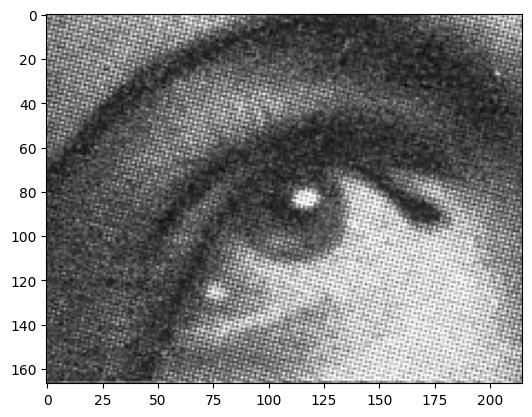

In [4]:
plt.imshow(img, cmap='gray')
plt.savefig("appfilter.png")

In this reading, we will try to remove the noise in this image. First, we will use random kernels.

Define a kernel.

In [5]:
filter1 = np.zeros(shape=(5,5))
filter1[2,2] = 1
filter1

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Apply a kernel on the image.


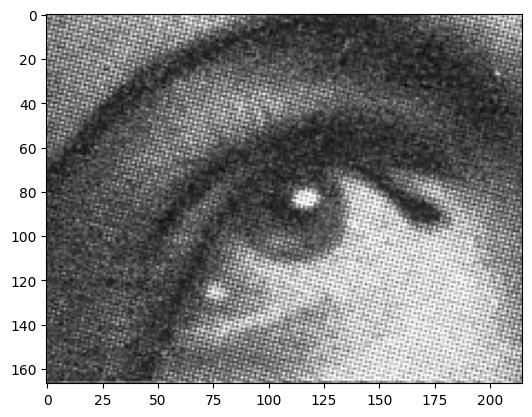

In [6]:
apply_filter1 = cv2.filter2D(img,-1,filter1)
plt.imshow(apply_filter1, cmap='gray')
plt.savefig("filter1.png")

It seems like nothing happened with the image. Let's verify it.

In [7]:
assert np.asarray(img).any() == np.asarray(apply_filter1).any()

What happened here?
* It is because the middle value of the kernel is one, and everything is zero. The convolution operation makes no changes to the image.

Let's use random numbers generator to generate numbers on the kernel and use it as a filter.

In [8]:
np.random.seed(0)
filter2 = np.array(np.random.randint(-3,3, size=(3, 3)))
filter2

array([[ 1,  2, -3],
       [ 0,  0,  0],
       [-2,  0,  2]])

Apply `filter2` on the image.

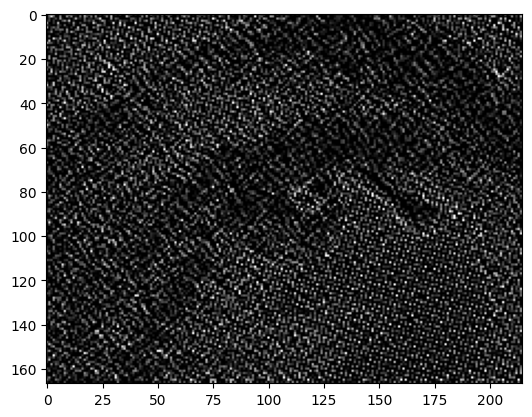

In [10]:
apply_filter2 = cv2.filter2D(img,-1,filter2)
plt.imshow(apply_filter2, cmap='gray')
# plt.savefig('randomfilter.png')
plt.show()
plt.close()

After applying random filter to the image, the object inside the image is gone. Therefore, all filters are not useful. Using a random filter makes no sense. Instead of having this random output, we need a filter that removes the noise on images. There are different types of spatial smoothing filters to solve this problem. Let’s discuss them.

## Spatial filtering and its Types




<center>

<!-- ![image](https://drive.google.com/uc?export=view&id=11mecG7yI7Jjp9G7NnkKYjxyr0Kn6YRU8) -->
![image](https://i.postimg.cc/gcSyWBWQ/image.png)
<figcaption>Figure 2: Types of spatial filters </figcaption>
</center>


Spatial smoothing filters are of two types:
* Linear and
* non-linear filters

In linear filters, we will discuss the box filter and Gaussian filter. This portion, however, does not contain details about nonlinear filters. The two powerful nonlinear filters are median and extended Kalman filters.

Keep two points in mind:
- There exist other linear and nonlinear filters.
- This portion will only discuss filters' applications, especially the box filter and Gaussian filter in the abstract.




## 2D Linear Image Filtering

In Linear filtering, the output is the linear combination of the neighborhood pixels. That means it is a sum of product between the image $f(x,y)$ and kernel $K$.


${g(x,y) = K(-1,-1) f(x-1, y-1) + K(-1,0) f(x-1,y) + .... + K(0,0) f(x,y) + ... + K(1,1) f(x+1, y+1)}$


The given formula illustrates the mechanics of linear spatial filtering using a kernel. At any point $\text{(x, y)}$ in the image, the response,
$\text{g(x, y)}$, of the filter is the sum of products of the kernel coefficients and the image pixels encompassed by the kernel.


As coordinates  $\text{x and y}$ are varied, the center of the kernel moves from pixel to pixel, generating the filtered image, g, in the process

Linear filtering is used to reduce the effect of Noise. $_{[2]}$
In linear filtering, the output is a linear function of Input.
If you shift the input image two pixels to the left, then the output will move two pixels to the left.

Let's first start with linear filters: first box filter.


## Box filter Kernel

A simplest linear filter is box filter or the moving average filter, which simply averages
the pixel values in a image window. This is equivalent to convolving the image with a kernel
of all ones and then scaling.


<center>

<!-- ![image](https://drive.google.com/uc?export=view&id=1A_LUcdQZl5upP8bozk26edmpotrucRYD) -->

![image](https://i.postimg.cc/mkJFFJZr/image.png)

<figcaption>Figure 3: 5 x 5 Normalized Box filter </figcaption>
</center>


This normalization, which we apply to all lowpass kernels, has two purposes.
- The average value of an area of constant intensity would equal that intensity in the filtered image, as it should.
- Normalizing the kernel in this way prevents introducing a bias during filtering




We will discuss the box filter in detail in the motion blur and box filter chapter. In this section, we will use a box filter kernel to remove noise on the image.


In [11]:
import cv2
import numpy as np
# initialize noise image with zeros
img = cv2.imread('gaussian.PNG',1)

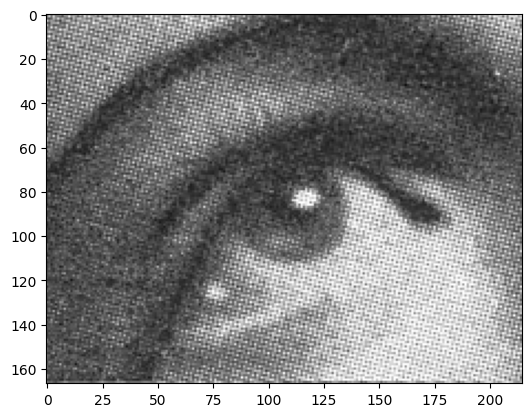

In [12]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

_Define kernel and apply it to original image._

In [13]:
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)

In [14]:
print(kernel)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


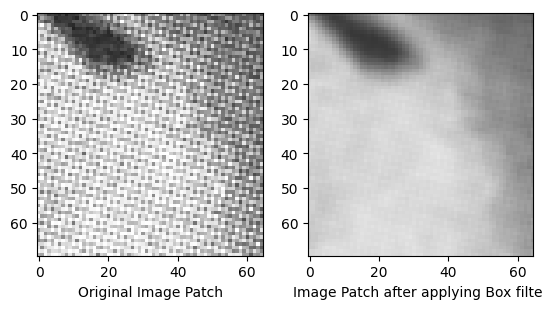

In [15]:
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1)
imgplot = plt.imshow(img[80:150, 150:230 ])
ax.set_xlabel('Original Image Patch')
ax = fig.add_subplot(1, 2, 2)
imgplot = plt.imshow(dst[80:150, 150:230 ])
ax.set_xlabel('Image Patch after applying Box filter')
plt.show()
plt.close()

 The effect of the kernel is important because changing value in kernel changes the Output of the Image.

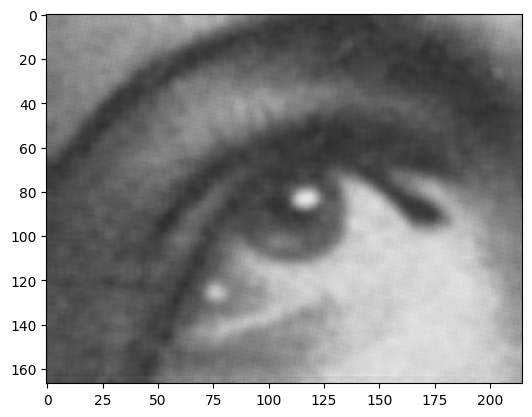

In [16]:
plt.imshow(dst)
# plt.savefig('boxfilter.png')

_Display image after applying kernel._

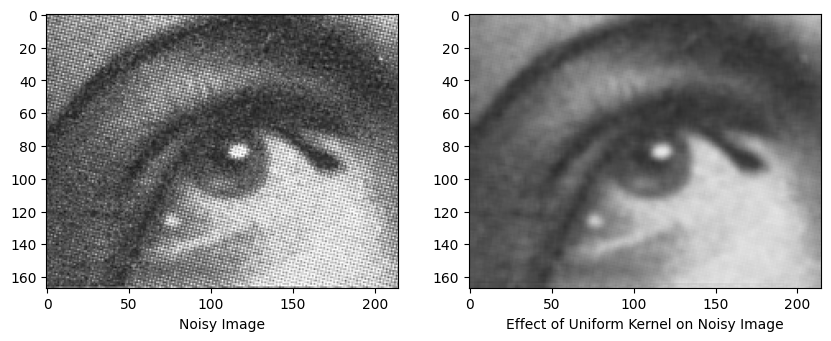

In [17]:
#@title Plot Images
fig, axes= plt.subplots(nrows=1, ncols=2,figsize=(10,10))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.setp(axes[0], xlabel='Noisy Image')
plt.setp(axes[1], xlabel='Effect of Uniform Kernel on Noisy Image')
# fig.tight_layout()
# plt.savefig('2DlinearUniform.png')
plt.show()

You can see drastic impact and results in the image because of the kernel. The noise is gone.

There is another linear filter named Gaussian filter. Let's discuss about it.

## Gaussian Filter



In `Gaussian Sampling and Median Filtering,` You will learn about Gaussian filter In detail. In this section, we will see the Implementation of the Gaussian Filter. Before starting, let's note down key points of the Gaussian Filter.


Gaussian sampling or filtering is a linear filtering technique that uses a gaussian kernel. Gaussian filtering/blur is used in image processing to reduce the amount of noise and remove speckles within the image. In any case, you focus on extracting a coarser detail and feature at a higher abstraction; then, you can use this filtering method.

There is one another exciting feature of the Gaussian filter.

* Gaussian filter is linearly separable. It means we can break any 2-d filter into two 1-d filters. So that the computational complexity reduces from $O(n^2)$ to $O(n).$ Let’s see an example.


*Use OpenCV [getGaussianKernel](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gac05a120c1ae92a6060dd0db190a61afa) method to get gaussian kernel for given kernel size(ksize) and the Gaussian standard deviation(sigma). This method returns 1D gaussian filter.*

In [18]:
oned = cv2.getGaussianKernel(ksize=3, sigma=10)
oned

array([[0.33277732],
       [0.33444537],
       [0.33277732]])

To convert it into a 2D kernel, multiply it with its transpose.

In [19]:
twod = np.dot(oned, oned.T)
twod

array([[0.11074074, 0.11129583, 0.11074074],
       [0.11129583, 0.1118537 , 0.11129583],
       [0.11074074, 0.11129583, 0.11074074]])

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'cmap'

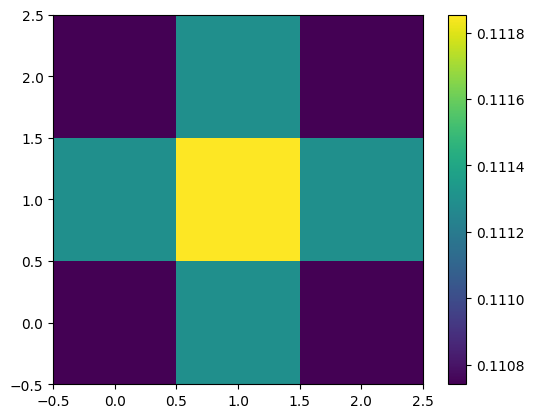

In [20]:
#@title Let's visualize the kernel
plt.imshow(twod, interpolation='none', origin='lower')
plt.colorbar()
# plt.xlabel("3*3 Gaussian Kernel")
plt.savefig('ksize3gauss.png',cmap=plt.get_cmap('jet'))
plt.show()
plt.close()

Using a similar approach, let's visualize a 5*5 kernel with sigma =2. You can change the value of ksize and sigma and play with the code.

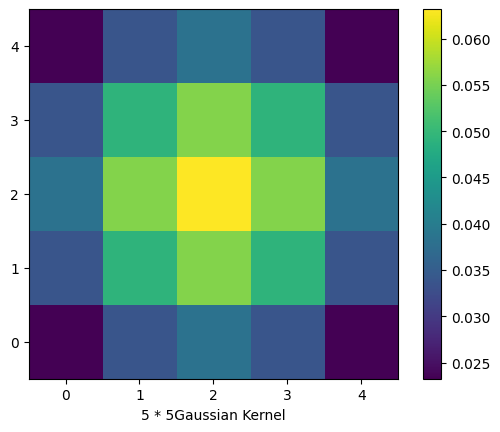

In [21]:
ksize=5
sigma=2
oned = cv2.getGaussianKernel(ksize=ksize, sigma=sigma)
twod = np.dot(oned, oned.T)
plt.imshow(twod, interpolation='none', origin='lower')
plt.colorbar()
plt.xlabel("{} * {}Gaussian Kernel".format(ksize, ksize))
plt.savefig('ksize5gauss.png')
plt.show()
plt.close()

Now let's focus on our goal to denoise the image.

*Use OpenCV [GaussianBlur](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_filtering/py_filtering.html) method to apply gaussian filter for given image.*

Let's first read the noisy image and apply (3,3) gaussian kernel on image and visualise the results.

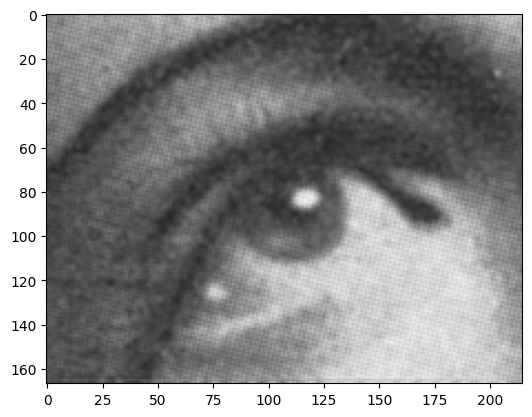

In [22]:
img = cv2.imread('gaussian.PNG',1)
kernel_size = (3,3)
blur_3 = cv2.GaussianBlur(img,kernel_size,10,10)
plt.imshow(blur_3)

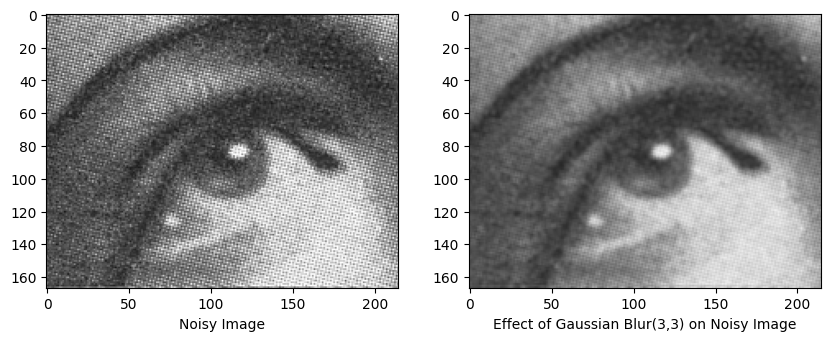

In [23]:
#@title Results of 3*3 kernel.

fig, ax = plt.subplots(1,2,figsize = (10,10))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_xlabel('Noisy Image')
ax[1].imshow(cv2.cvtColor(blur_3, cv2.COLOR_BGR2RGB))
ax[1].set_xlabel('Effect of Gaussian Blur(3,3) on Noisy Image')
plt.show()

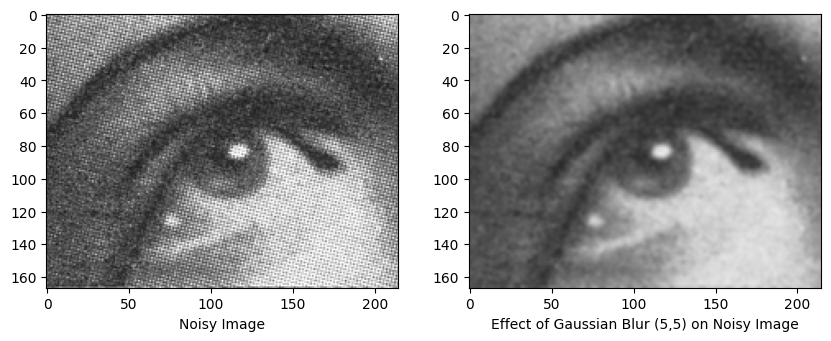

In [24]:
#@title Let's use 5*5 kernel.
kernel_size = (5,5)
blur_5 = cv2.GaussianBlur(img,(5,5), 0)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize = (10,10))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_xlabel('Noisy Image')
ax[1].imshow(cv2.cvtColor(blur_5, cv2.COLOR_BGR2RGB))
ax[1].set_xlabel('Effect of Gaussian Blur (5,5) on Noisy Image')
plt.show()

If you pass 0 as an argument in `GaussianBlur()` method it automatically finds value of standred deviation.

_Larger sigma values may remove more noise, but they will also remove detail from an image._

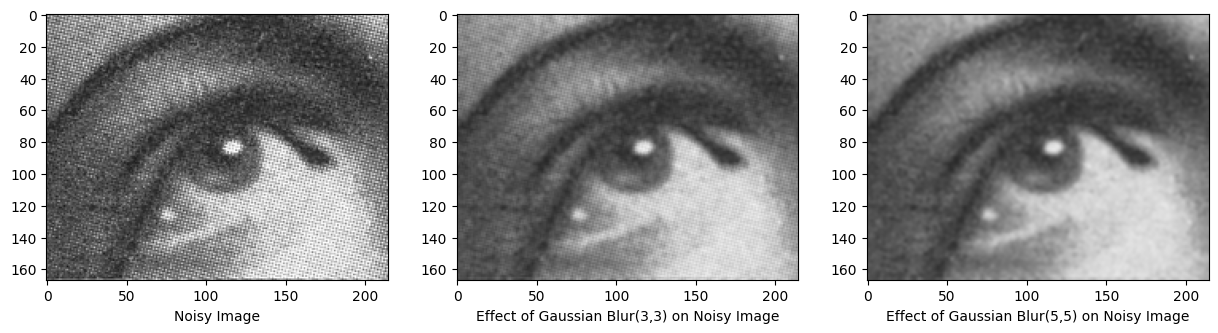

In [25]:
fig, ax = plt.subplots(1,3,figsize = (15,10))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_xlabel('Noisy Image')
ax[1].imshow(cv2.cvtColor(blur_3, cv2.COLOR_BGR2RGB))
ax[1].set_xlabel('Effect of Gaussian Blur(3,3) on Noisy Image')
ax[2].imshow(cv2.cvtColor(blur_5, cv2.COLOR_BGR2RGB))
ax[2].set_xlabel('Effect of Gaussian Blur(5,5) on Noisy Image')
plt.show()

This is simple and easy Implementation of different types of Image filters.

## Comparative study of Random filter, Box filter, and Gaussian filter

Let's compare the results we've obtained so far.

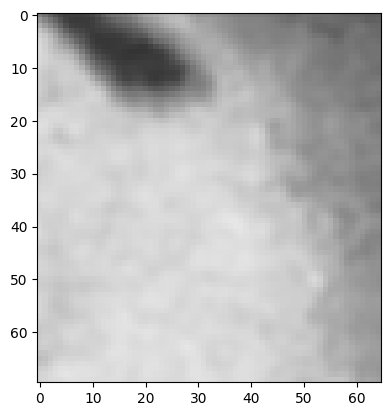

In [26]:
plt.imshow(blur_5[80:150, 150:230 ],cmap='gray')

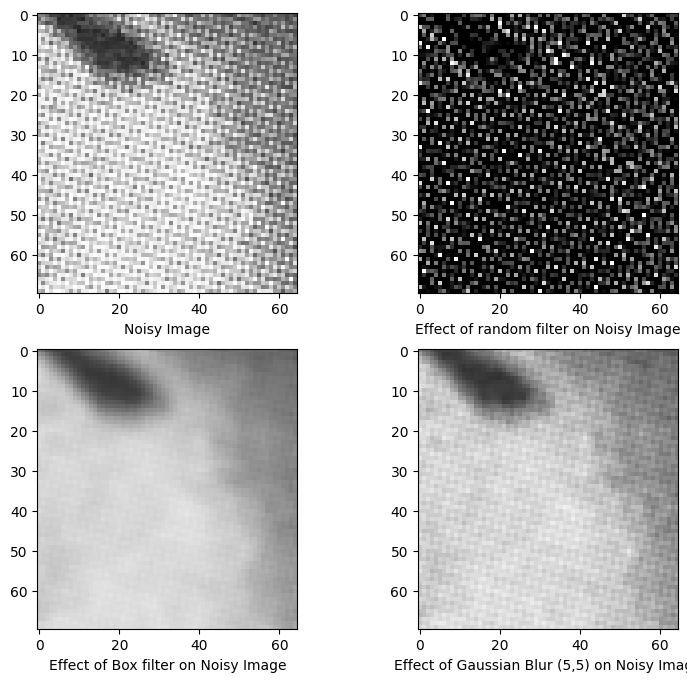

In [27]:
#@title Compare
fig, axes= plt.subplots(2,2,figsize=(9,8))
axes[0,0].imshow(img[80:150, 150:230 ],cmap='gray')
axes[0,1].imshow(apply_filter2[80:150, 150:230 ], cmap='gray')
plt.setp(axes[0,0], xlabel='Noisy Image')
plt.setp(axes[0,1], xlabel='Effect of random filter on Noisy Image')
# axes[1,0].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
axes[1,0].imshow(dst[80:150, 150:230 ])
plt.setp(axes[1,0], xlabel='Effect of Box filter on Noisy Image')
axes[1,1].imshow(blur_3[80:150, 150:230 ])
plt.setp(axes[1,1], xlabel='Effect of Gaussian Blur (5,5) on Noisy Image')
# fig.tight_layout()
# plt.savefig('filter_compare.png')
plt.show()

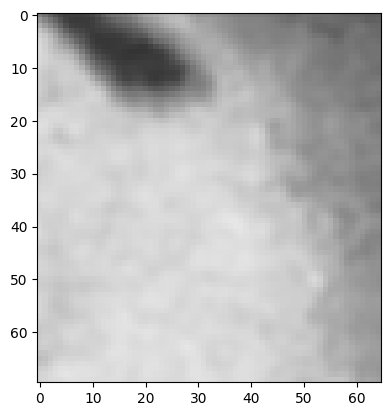

In [28]:
plt.imshow(blur_5[80:150, 150:230 ])

Different filter results in different Image as output. A random filter is always risky to use; it might make the Image look rubbish. A structured box and gaussian helps you to remove noise that comes from a Gaussian distribution. The difference is in the iris area of the eye. There exist non-linear filters too. That uses statistics to enhance image quality. Therefore you should deal with filters according to the use case.



## Key Take Aways

- You can use filters to modify the Images. This modification will allow you to get clear pictures.


- You can apply filters to gain specific information about the image.

- Instead of having this random output using random filters, we want to structure filter operation on images.

-  Gaussian filter is a linear filter.


